# SIMULADO INTERMEDIÁRIO

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from graph_tool.all import *

In [2]:
sns.set()

**Qual é o conceito de rede que representa a quantidade de colegas com quem um colaborador troca informações?**

Grau. *(em redes não-dirigidas não existe "de entrada" e "de saída")*

**Qual é a métrica de rede vista em aula que representa o conceito de "trabalhar em ambientes bem conectados" usado no email?**

Coeficiente de agrupamento local. *(Aula 8)*

**Justifique a escolha a partir da definição formal da métrica.**

O coeficiente de agrupamento local mede a probabilidade de seus contatos estarem conectados entre si, formando grupos coesos em vez de conexões isoladas. Isso quantifica o conceito de ambiente bem conectado ao mostrar quão integrada e colaborativa é a rede ao seu redor.

**Carregue a rede.**

In [3]:
g = load_graph('simulado.gt')

**Visualize a rede.**

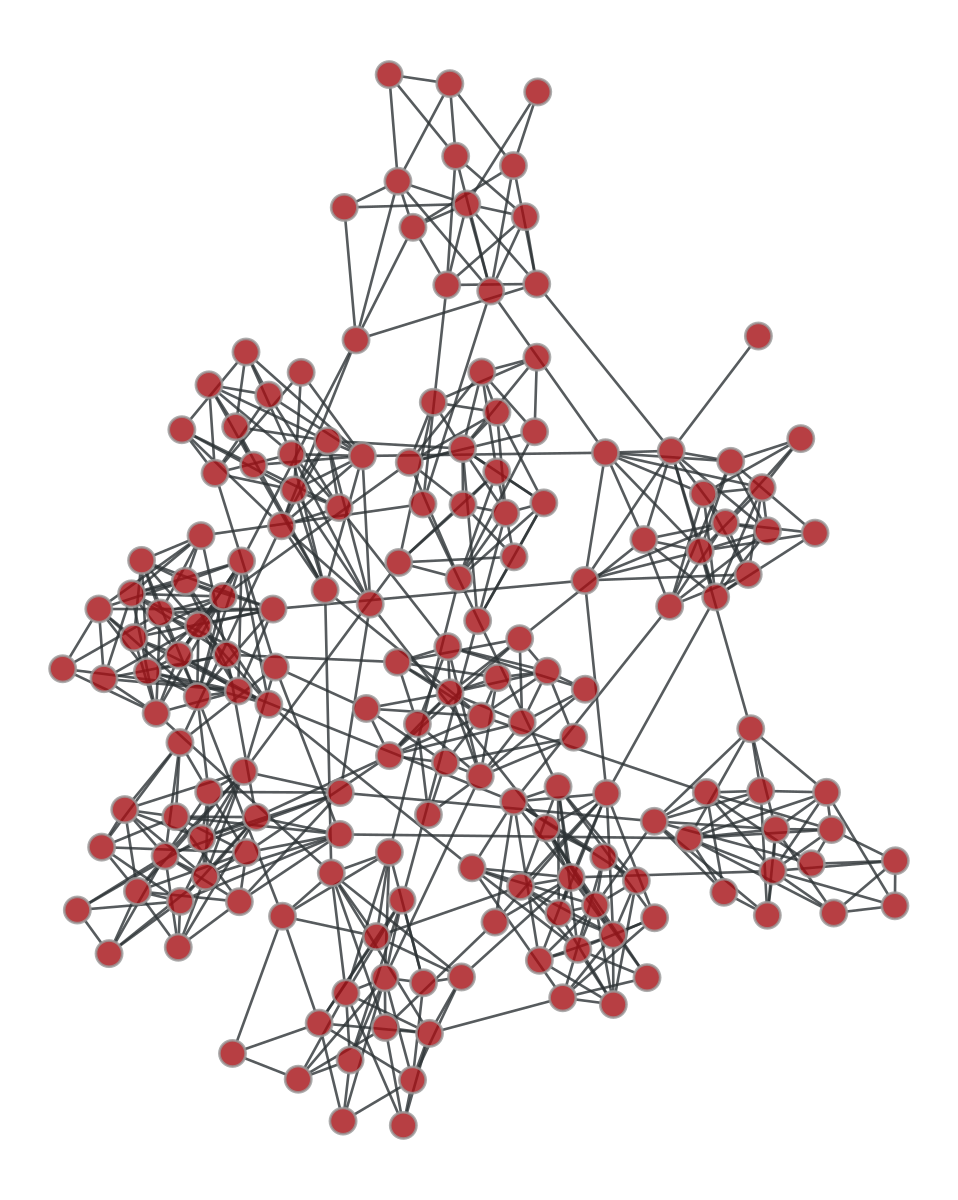

In [4]:
graph_draw(g);

**Obtenha a percepção de eficácia pessoal dos colaboradores.**

In [5]:
eficacia = g.vp['eficacia']

**Construa um dataframe em que as colunas correspondem à Variável A, à Variável B e a essa percepção de eficácia.**

In [6]:
df = pd.DataFrame({
    'grau': [v.out_degree() for v in g.vertices()],
    'agrupamento': local_clustering(g),
    'eficacia': eficacia,
})

**A percepção de eficácia pessoal é a resposta que cada colaborador deu à afirmação "sou capaz de atingir os objetivos estabelecidos". Ela vai de 1 ("discordo totalmente") até 5 ("concordo totalmente"). Essa variável é...**

qualitativa ordinal. *(valores são qualitativos e têm ordem)*

**Implemente uma regressão linear em que a dependente é eficácia pessoal e as independentes são a _Variável A_ e a _Variável B_.**

In [7]:
dep = df['eficacia']

ind = df[['grau', 'agrupamento']]
ind = sm.add_constant(ind)

model = sm.OLS(dep, ind)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               eficacia   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     81.55
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.95e-25
Time:                        17:08:12   Log-Likelihood:                -253.84
No. Observations:                 170   AIC:                             513.7
Df Residuals:                     167   BIC:                             523.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2291      0.388     -0.590      0.556      -0.996       0.537
grau            0.4950      0.040     12.337      0.000       0.416       0.574
agrupamento    -0.5577      0.632     -0.883      0.379      -1.805       0.690
==============================================================================
Omnibus:                      232.986   Durbin-Watson:                   1.970
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            33487.135
Skew:                          -5.247   Prob(JB):                         0.00
Kurtosis:                      70.952   Cond. No.                         60.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Plote os três gráficos de resíduos dessa regressão.**

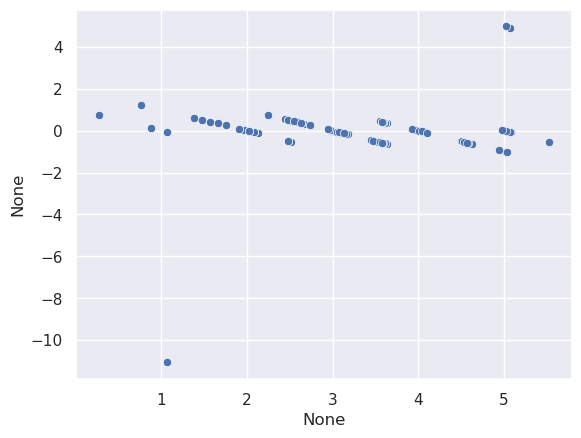

In [8]:
sns.scatterplot(x=result.fittedvalues, y=result.resid);

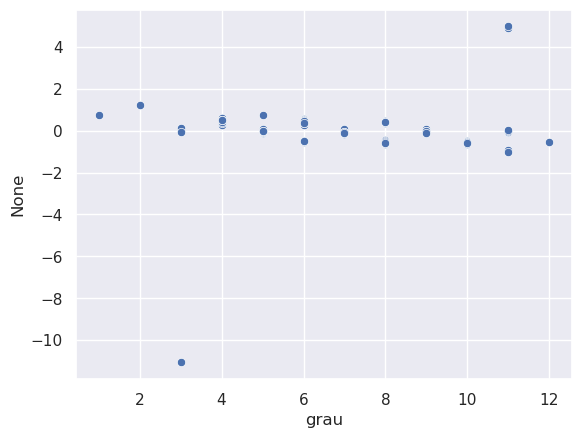

In [9]:
sns.scatterplot(x=df['grau'], y=result.resid);

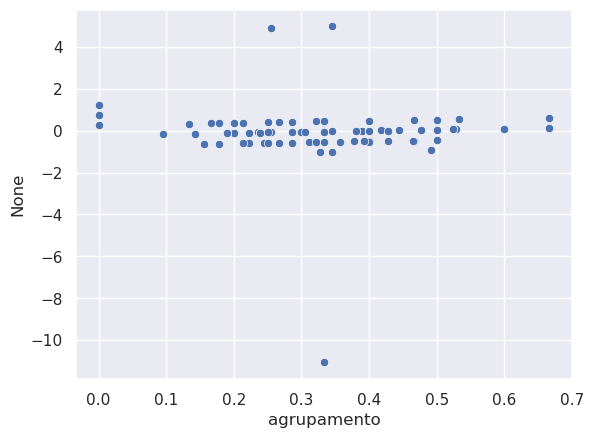

In [10]:
sns.scatterplot(x=df['agrupamento'], y=result.resid);

**Considerando os resultados da regressão com uma confiança de 95%, parece haver relação entre grau e eficácia? Por quê? Qual?**

Parece haver relação positiva, pois o coeficiente é positivo e o valor-p está abaixo de `0.05`.

**Considerando os resultados da regressão com uma confiança de 95%, parece haver relação entre agrupamento e eficácia? Por quê? Qual?**

Não parece haver relação, pois o valor-p está muito acima de `0.05`.

**O que você modificaria na implementação dessa análise? Justifique.**

Analisando os gráficos de resíduos, podemos perceber que os pressupostos da regressão linear parecem ser invalidados por três observações que destoam muito das restantes. Para justificar isso, podemos pensar em duas possibilidades:

* a relação da dependente com as independentes não é linear;
* essas observações são outliers e podem ser desconsideradas.

Analisando os valores de eficácia, podemos perceber que elas estão fora do intervalo de valores dado pela definição.

In [11]:
df['eficacia'].value_counts()

eficacia
 3.0     77
 2.0     42
 4.0     37
 1.0      6
 5.0      5
 10.0     2
-10.0     1
Name: count, dtype: int64

Parece plausível, portanto, considerá-las como outliers. Disso seguem duas modificações possíveis:

* desconsiderar as observações;
* truncar os valores para o intervalo `[1, 5]`.

Vamos implementar a primeira. *(a segunda também seria aceita, até porque os resultados seriam análogos)*

**Implemente a modificação.**

In [12]:
df = df[(df['eficacia'] >= 1) & (df['eficacia'] <= 5)]

In [13]:
dep = df['eficacia']

ind = df[['grau', 'agrupamento']]
ind = sm.add_constant(ind)

model = sm.OLS(dep, ind)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               eficacia   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     563.2
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.44e-74
Time:                        17:08:13   Log-Likelihood:                -38.978
No. Observations:                 167   AIC:                             83.96
Df Residuals:                     164   BIC:                             93.31
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6834      0.112      6.088      0.000       0.462       0.905
grau            0.3743      0.012     31.791      0.000       0.351       0.398
agrupamento    -0.8049      0.180     -4.483      0.000      -1.159      -0.450
==============================================================================
Omnibus:                       22.438   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                6.501
Skew:                           0.072   Prob(JB):                       0.0388
Kurtosis:                       2.044   Cond. No.                         59.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Plote os novos resíduos.**

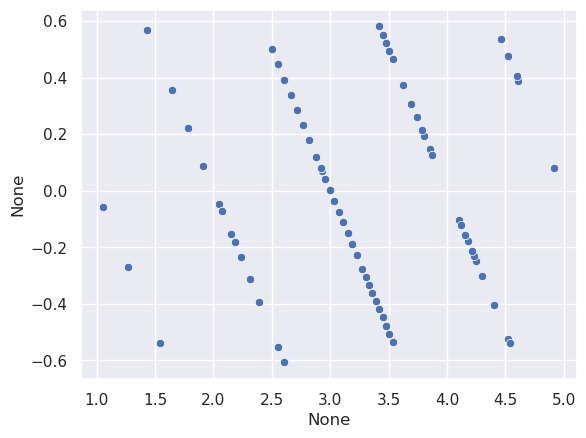

In [14]:
sns.scatterplot(x=result.fittedvalues, y=result.resid);

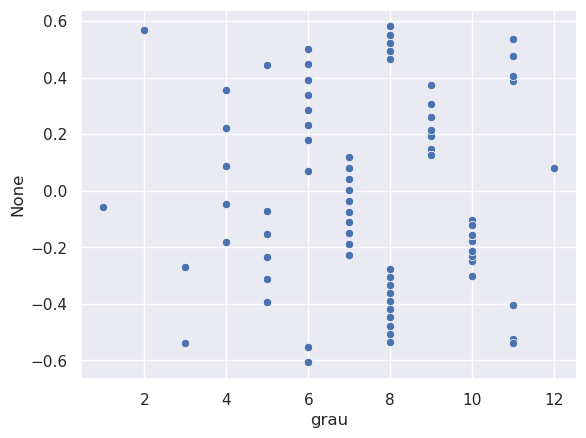

In [15]:
sns.scatterplot(x=df['grau'], y=result.resid);

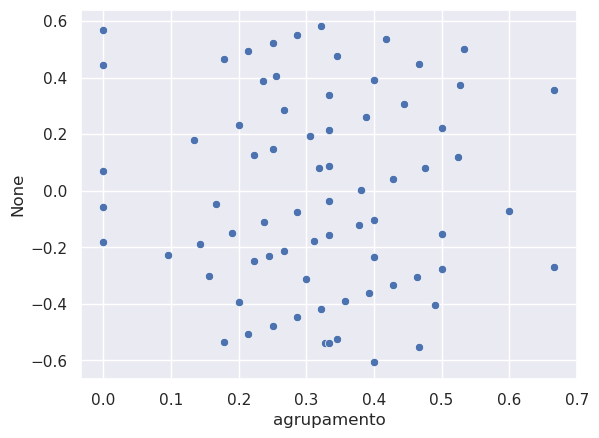

In [16]:
sns.scatterplot(x=df['agrupamento'], y=result.resid);

**Considerando os resultados da _nova_ regressão com uma confiança de 95%, parece haver relação entre grau e eficácia? Por quê? Qual?**

Parece haver relação positiva, pois o coeficiente é positivo e o valor-p está abaixo de `0.05`.

**Considerando os resultados da _nova_ regressão com uma confiança de 95%, parece haver relação entre agrupamento e eficácia? Por quê? Qual?**

Parece haver relação negativa, pois o coeficiente é negativo e o valor-p está abaixo de `0.05`.

**Explique os resultados:**

* **justifique a relação (ou ausência de relação) constatada entre quantidade de colegas com quem um colaborador troca informações e eficácia pessoal;**
* **justifique a relação (ou ausência de relação) constatada entre trabalhar em ambientes bem conectados e eficácia pessoal.**

Trabalhar com muitos colegas aumenta a eficácia pessoal ao garantir acesso rápido a uma diversidade de conhecimentos e recursos que seriam inacessíveis em isolamento. Além disso, essa ampla rede de troca reduz o tempo gasto na resolução de problemas, permitindo que o colaborador utilize soluções já validadas por outros.

Em ambientes que exigem inovação e criatividade, um alto coeficiente de agrupamento indica que você está preso a uma "bolha" onde todos compartilham as mesmas informações redundantes. Isso prejudica a eficácia porque limita o acesso a ideias externas e novas perspectivas, tornando o colaborador um prisioneiro do pensamento de grupo.